# NDVI blood perfusion with Cuvis.AI

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cubert-hyperspectral/cuvis-ai/blob/main/notebooks/use_cases/blood_perfusion.ipynb)

This tutorial takes a hyperspectral CU3S session of a hand and builds a
**blood-perfusion video** by applying a Normalized Difference Vegetation
Index (NDVI) projection between a near-infrared (NIR) band and a visible
"red" band. The same NDVI idea that flags chlorophyll in plants flags
**haemoglobin** in tissue — high NDVI means more blood in the optical
path (perfusion), *not* necessarily oxygenated blood.

We build a three-node Cuvis.AI pipeline:

```
CU3SDataNode  ──►  NDVISelector  ──►  ToVideoNode
```

> **Prerequisites**
>
> 1. Install cuvis-ai — see the [Installation Guide](https://docs.cuvis.ai/latest/user-guide/installation/).
> 2. From the cuvis-ai env, launch the notebook with `uv run jupyter lab`.

In [1]:
# Colab bootstrap — no-op when running locally
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # cuvis-ai itself; the next cell provisions the plugins from the packaged manifests.
    %pip install -q cuvis-ai
    !which ffmpeg dot >/dev/null || echo "WARN: ffmpeg/dot missing on this runtime"

    import torch

    if not torch.cuda.is_available():
        print(
            "WARNING: No GPU detected. Switch via Runtime > Change runtime type > T4 GPU. "
            "CPU runs are slow (perfusion ~10x, SAM3 passive ~80x)."
        )

In [ ]:
# Provision the plugins this notebook needs. Their pins live in the plugin manifests packaged with
# cuvis-ai (cuvis_ai/configs/plugins): `provision` reads them off a packaged pipeline that uses the
# same plugins, adds the data module's extras, and installs only what is missing. After a fresh
# install, restart the kernel (Kernel > Restart Kernel) and rerun from the top.
from importlib.resources import files

from cuvis_ai_core.utils.provision import provision_environment, resolve_install_specs

CONFIGS = files("cuvis_ai") / "configs"
PLUGINS_DIR = CONFIGS / "plugins"
PROVISION = [  # (packaged pipeline that lists the plugin(s), data module whose extras to add)
    ("medical/blood_perfusion/ndvi.yaml", "cu3s"),  # builtin nodes: only the cu3s data module
]
for pipeline_yaml, data_module in PROVISION:
    pipeline_path = CONFIGS / "pipeline" / pipeline_yaml
    if IN_COLAB:  # no uv project on Colab: pip the resolved specs straight into this kernel
        specs = resolve_install_specs(pipeline_path, [PLUGINS_DIR], data_module)
        provision_environment(specs, notebook=True, apply=True)
    else:  # the same command you would run in a terminal from the repo root
        data_arg = f"--data-module {data_module}" if data_module else ""
        !uv run provision --pipeline-path "{pipeline_path}" --plugins-dir "{PLUGINS_DIR}" {data_arg} --apply

In [2]:
%matplotlib inline
from __future__ import annotations

from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import torch
from cuvis_ai_dataloader.data import Cu3sDataModule
from cuvis_ai_schemas.pipeline import PortSpec
from IPython.display import Image, Video, display
from loguru import logger

from cuvis_ai.node.channel_selector import NDVISelector
from cuvis_ai.node.data import CU3SDataNode
from cuvis_ai.node.video import ToVideoNode
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_core.node import Node
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor

In [3]:
device = torch.device("cpu")
# Pick the best available torch device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
logger.info(f"Using device {device}")

2026-06-18 12:07:58.982 | INFO     | __main__:<module>:7 - Using device cuda


## 1 · Fetch the dataset

The XMR Blood Perfusion session (~11 GB) lives on Hugging Face Hub. The cell
below checks for the file and downloads via `PublicDatasets.download_dataset`
if missing — equivalent to running `uv run dataset download blood_perfusion`
from a terminal.

In [4]:
dataset_dir = Path("/content/data") if IN_COLAB else Path("../../data")

_ = PublicDatasets.download_dataset(
    "blood_perfusion",
    download_path=str(dataset_dir),
    force=False,
)

Dataset 'blood_perfusion' already exists at ..\..\data\XMR_Demo_Blood_Perfusion
Use force=True to re-download.


## 2 · What is NDVI?

**NDVI — Normalized Difference Vegetation Index** — was invented in the
1970s to map healthy vegetation from satellite imagery. It is a
pixel-wise contrast between two wavelength bands, chosen to exploit how
*chlorophyll* behaves with light:

- **Red** ($\approx 620$–$680$ nm): the red end of the visible spectrum.
  Chlorophyll absorbs heavily here, so green leaves reflect very little
  red light.
- **Near-infrared (NIR)** ($\approx 760$–$900$ nm): just past the red
  end of visible — the eye can't see it. Internal leaf scattering makes
  vegetation a strong NIR *reflector*.

(For orientation: visible light covers $\approx 380$–$740$ nm; NIR runs
from there out to $\approx 1400$ nm. Both are easily within reach of a
Cubert hyperspectral camera.)

A pixel of healthy vegetation therefore has a big gap between
$R_{\mathrm{NIR}}$ and $R_{\mathrm{Red}}$. The contrast is normalized so
the index does not depend on overall brightness:

$$
\mathrm{NDVI}(x, y) =
  \frac{R_{\mathrm{NIR}}(x, y) - R_{\mathrm{Red}}(x, y)}
       {R_{\mathrm{NIR}}(x, y) + R_{\mathrm{Red}}(x, y)}
$$

where $R_{\mathrm{NIR}}(x, y)$ and $R_{\mathrm{Red}}(x, y)$ are the
per-pixel **reflectance** values — the fraction of incident light
returned by the surface, in $[0, 1]$ — sampled from the hyperspectral
cube by nearest-wavelength match to `NIR_NM` and `RED_NM`.

NDVI itself is bounded in $[-1, +1]$, with rough rules of thumb on
satellite imagery:

- $+0.6$ to $+0.9$ — dense, healthy vegetation
- $\approx 0$ — bare soil, rocks, dead plants
- $< 0$ — water, snow, clouds

**Why we use it for blood perfusion.** Same idea, different chromophore.
Swap *chlorophyll* for *haemoglobin* and re-pick the bands: at NIR
$\approx 750$ nm tissue is fairly transparent, while at the visible band
$\approx 566$ nm both oxy- and deoxy-haemoglobin absorb strongly. The
index is then dominated by **how much haemoglobin sits in the optical
path** — i.e. blood volume — so pixels with more blood drive NDVI up.
That is a **perfusion** signal.

This is *not* a clean oxygenation (SpO2) measurement. An **isosbestic
point** is a wavelength where oxy-haemoglobin and deoxy-haemoglobin
absorb *equally*; the signal there reflects total haemoglobin and is
blind to its oxygenation state. Visible-light isosbestics for
haemoglobin sit at $\approx 545$, $570$, and $584$ nm, with another in
the NIR around $800$ nm. 566 nm sits *near* the $\sim 570$ nm one but
not exactly on it, so the index couples only weakly to oxygenation;
isolating SpO2 requires a different wavelength choice and a multi-band
model (we sketch that in §8).

`NDVISelector` resolves each of `nir_nm` / `red_nm` to the nearest
sensor wavelength, computes NDVI for every pixel of every frame, and
maps the result to an RGB frame via an HSV-style colormap.
`colormap_min` / `colormap_max` clip the ends of the scale.

## 3 · Tutorial configuration

Each knob below is safe to edit.

- **`NIR_NM` / `RED_NM`** — the two wavelengths NDVI differences over.
  The 750 / 566 nm pair is tuned for haemoglobin contrast (see §2).
- **`COLORMAP_MIN` / `COLORMAP_MAX`** — NDVI values below/above these
  saturate to the colormap's endpoints. Tighten the range to exaggerate
  small contrasts.
- **`TOTAL_FRAMES`** — known length of the XMR Blood Perfusion session
  (568 frames).
- **`N_FRAMES`** — how many frames to process. Drop to 20 for a fast
  first run.
- **`FRAME_RATE`** — output video FPS.
- **`FRAME_ROTATION`** — degrees to rotate each frame (e.g. 90, 180) or
  `None`.

In [5]:
NIR_NM = 750.0
RED_NM = 566.0
COLORMAP_MIN = -0.7
COLORMAP_MAX = 0.5

TOTAL_FRAMES = 568
N_FRAMES = TOTAL_FRAMES
FRAME_RATE = 15.0
FRAME_ROTATION: int | None = None

output_dir = Path("./output/blood_perfusion")
output_video_path = output_dir / "ndvi_projection.mp4"
output_dir.mkdir(parents=True, exist_ok=True)
cu3s_file_path = dataset_dir / "XMR_Demo_Blood_Perfusion" / "Auto_005.cu3s"

print(f"Will process {N_FRAMES}/{TOTAL_FRAMES} frames at {FRAME_RATE} fps")
print(f"Output: {output_video_path}")

Will process 568/568 frames at 15.0 fps
Output: output\blood_perfusion\ndvi_projection.mp4


## 4 · Build the pipeline

Three nodes, four connections:

- `CU3SDataNode` unpacks each batch of CU3S measurements into a
  `[B, H, W, C]` float cube plus the 1-D wavelength vector.
- `NDVISelector` consumes the cube and wavelengths, emits a colour-mapped
  `rgb_image` plus the raw `index_image`.
- `ToVideoNode` writes the RGB frames to an MP4, using `frame_id`
  (the measurement index) as an on-screen overlay.

In [6]:
pipeline = CuvisPipeline("BloodPerfusion_NDVI_Projection")
cu3s_data = CU3SDataNode(name="cu3s_data")
ndvi = NDVISelector(
    nir_nm=NIR_NM,
    red_nm=RED_NM,
    colormap_min=COLORMAP_MIN,
    colormap_max=COLORMAP_MAX,
    name="ndvi",
)
to_video = ToVideoNode(
    output_video_path=str(output_video_path),
    frame_rate=FRAME_RATE,
    frame_rotation=FRAME_ROTATION,
    name="to_video",
)

pipeline.connect(
    (cu3s_data.outputs.cube, ndvi.cube),
    (cu3s_data.outputs.wavelengths, ndvi.wavelengths),
    (ndvi.rgb_image, to_video.rgb_image),
    (cu3s_data.outputs.mesu_index, to_video.frame_id),
)

2026-06-18 12:07:59.443 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\blood_perfusion\BloodPerfusion_NDVI_Projection.png


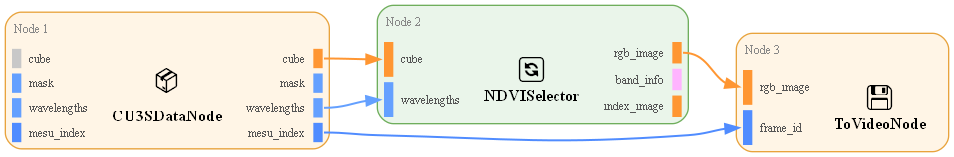

2026-06-18 12:07:59.449 | INFO     | cuvis_ai_core.pipeline.pipeline:save_to_file:467 - Pipeline saved: Config=output\blood_perfusion\BloodPerfusion_NDVI_Projection.yaml (weights skipped)


In [7]:
graph_png = pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{pipeline.name}.png"),
    # show_execution_stage=True,
)
display(Image(str(graph_png)))

pipeline.save_to_file(
    str(output_dir / f"{pipeline.name}.yaml"),
    save_weights=False,
)

## 5 · Sanity-check on a single frame

Before committing to the full 568-frame sweep, render exactly one frame
end-to-end so we can verify wavelengths, colormap, orientation, and
overall sanity in seconds. Set `PREVIEW_FRAME_ID` to whichever frame you
want to inspect, then point a fresh `Cu3sDataModule` at just that
index. With `collect_outputs=True`, `Predictor.predict` captures the
rendered RGB tensor in a list of dicts keyed by `(node_name, port_name)`,
which we plot inline.

*Note:* the main pipeline still includes `ToVideoNode`, so this run
writes a one-frame `.mp4` to `output_video_path`. §6 overwrites it on
the full sweep.

Predict [BloodPerfusion_NDVI_Projection]:   0%|          | 0/1 [00:00<?, ?batch/s]

2026-06-18 12:08:03.893 | DEBUG    | cuvis_ai_dataloader.data.readers.cu3s_reader:__init__:47 - Opened cu3s ..\..\data\XMR_Demo_Blood_Perfusion\Auto_005.cu3s: 568 measurements, 61 channels


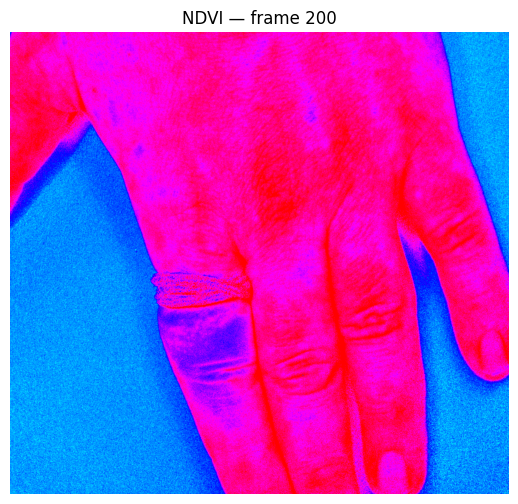

In [8]:
PREVIEW_FRAME_ID = 200

preview_datamodule = Cu3sDataModule(
    cu3s_file_path=str(cu3s_file_path),
    processing_mode="Reflectance",
    batch_size=1,
    measurement_indices=[PREVIEW_FRAME_ID],
)

pipeline.to(device)
preview_predictor = Predictor(pipeline=pipeline, datamodule=preview_datamodule)
preview_outputs = preview_predictor.predict(collect_outputs=True)

# Pull frame's RGB out of the (node_name, port_name) keyed dict
preview_rgb = preview_outputs[0][("ndvi", "rgb_image")][0].cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(preview_rgb)
plt.title(f"NDVI — frame {PREVIEW_FRAME_ID}")
plt.axis("off")
plt.show()

## 6 · Run the pipeline

`Predictor.predict` iterates batches from the `Cu3sDataModule` and
pushes each one through the connected pipeline. `max_batches=N_FRAMES`
caps the run; `collect_outputs=False` tells the predictor to discard
per-batch tensors after `ToVideoNode` has written them — important for
memory on the full 568-frame sweep.

In [9]:
datamodule = Cu3sDataModule(
    cu3s_file_path=str(cu3s_file_path),
    processing_mode="Reflectance",
    batch_size=1,
    measurement_indices=None,
)

pipeline.to(device)

predictor = Predictor(pipeline=pipeline, datamodule=datamodule)
predictor.predict(max_batches=N_FRAMES, collect_outputs=False)

if not output_video_path.exists():
    raise RuntimeError(f"Expected output video was not created: {output_video_path}")

logger.success("NDVI export complete: {}", output_video_path)

2026-06-18 12:08:05.260 | DEBUG    | cuvis_ai_dataloader.data.readers.cu3s_reader:__init__:47 - Opened cu3s ..\..\data\XMR_Demo_Blood_Perfusion\Auto_005.cu3s: 568 measurements, 61 channels


Predict [BloodPerfusion_NDVI_Projection]:   0%|          | 0/568 [00:00<?, ?batch/s]

2026-06-18 12:08:05.857 | DEBUG    | cuvis_ai_dataloader.data.readers.cu3s_reader:__init__:47 - Opened cu3s ..\..\data\XMR_Demo_Blood_Perfusion\Auto_005.cu3s: 568 measurements, 61 channels
2026-06-18 12:09:43.781 | SUCCESS  | __main__:<module>:16 - NDVI export complete: output\blood_perfusion\ndvi_projection.mp4


## 7 · Watch the result

In [10]:
display(Video(str(output_video_path), embed=IN_COLAB, width=640))

## 8 · Advanced technique: extending the framework with custom nodes

*Advanced section.* Everything above used only stock Cuvis.AI nodes.
The framework is designed to be extended — any class that follows the
`Node` contract (port `INPUT_SPECS` / `OUTPUT_SPECS` plus a `forward()`
method) drops straight into a `CuvisPipeline.connect(...)` graph
alongside the built-ins. We demonstrate by adding a *qualitative* SpO2
proxy on top of the perfusion pipeline.

The cleanest answer to "is this blood oxygenated?" is Beer-Lambert
linear unmixing across ≥3 wavelengths. The simpler 2-band version
mirrors the NDVI trick on a wavelength pair chosen for oxy/deoxy
contrast:

- **`deoxy_nm` ≈ 760 nm** — strong deoxy-Hb peak; oxy-Hb barely absorbs.
- **`oxy_nm` ≈ 577 nm** — β peak of oxy-Hb.

Computing $(R_\mathrm{deoxy} - R_\mathrm{oxy}) / (R_\mathrm{deoxy} +
R_\mathrm{oxy})$ produces an index that moves up with oxygenation.
Honest caveat: it still couples to blood volume and pigmentation — *not*
a calibrated SpO2.

Two custom nodes do the work:

- **`SpO2RatioSelector`** — extends `NDVISelector` and reuses its
  normalized-difference machinery; only the parameter names and defaults
  change.
- **`BloodHealthMaskNode`** — fresh `Node` that multiplies a colormapped
  RGB by a soft mask derived from the perfusion index, so SpO2 colour
  only shows up inside vessels.

The full pipeline forks the cube into both selectors, feeds the
perfusion *index* (raw scalar, before colormap) as a mask, and gates the
SpO2 colormap with it before writing a second video:

```
                   ┌─► NDVISelector ─── index_image ──┐
CU3SDataNode ──────┤                                  │
                   └─► SpO2RatioSelector ─ rgb_image ─┴─► BloodHealthMaskNode ──► ToVideoNode
```

**Pipeline persistence.** These classes live only in this notebook.
`restore_pipeline` and `restore_trainrun` deserialize nodes by class
name through the cuvis-ai-core node registry, so a saved pipeline that
references `SpO2RatioSelector` cannot be rehydrated elsewhere. To make
custom nodes restoreable, package them as a plugin (loadable via
`NodeRegistry().register_plugin(...)`) or contribute them to the Cuvis.AI
built-ins.

In [11]:
class SpO2RatioSelector(NDVISelector):
    """Two-band SpO2 proxy: NDVI applied on a (deoxy, oxy) wavelength pair."""

    def __init__(
        self,
        deoxy_nm: float = 760.0,
        oxy_nm: float = 577.0,
        **kwargs: Any,
    ) -> None:
        kwargs.setdefault("colormap_min", -0.3)
        kwargs.setdefault("colormap_max", 0.3)
        super().__init__(nir_nm=deoxy_nm, red_nm=oxy_nm, **kwargs)


class BloodHealthMaskNode(Node):
    """Multiply an RGB image by a soft mask derived from a scalar perfusion index."""

    INPUT_SPECS = {
        "rgb_image": PortSpec(dtype=torch.float32, shape=(-1, -1, -1, 3)),
        "perfusion_index": PortSpec(dtype=torch.float32, shape=(-1, -1, -1, 1)),
    }
    OUTPUT_SPECS = {
        "rgb_image": PortSpec(dtype=torch.float32, shape=(-1, -1, -1, 3)),
    }

    def __init__(self, mask_low: float = -0.1, mask_high: float = 0.2, **kwargs: Any) -> None:
        super().__init__(mask_low=float(mask_low), mask_high=float(mask_high), **kwargs)
        self.mask_low = float(mask_low)
        self.mask_high = float(mask_high)

    def forward(
        self,
        rgb_image: torch.Tensor,
        perfusion_index: torch.Tensor,
        **_: Any,
    ) -> dict[str, torch.Tensor]:
        """Soft-mask an RGB image by a scalar perfusion index in [mask_low, mask_high]."""
        span = self.mask_high - self.mask_low
        mask = ((perfusion_index - self.mask_low) / span).clamp(0.0, 1.0)
        return {"rgb_image": rgb_image * mask}

In [12]:
advanced_output_path = output_dir / "spo2_proxy_masked.mp4"

advanced_pipeline = CuvisPipeline("BloodPerfusion_SpO2_Masked")
adv_cu3s = CU3SDataNode(name="cu3s_data")
adv_perfusion = NDVISelector(
    nir_nm=NIR_NM,
    red_nm=RED_NM,
    colormap_min=COLORMAP_MIN,
    colormap_max=COLORMAP_MAX,
    name="perfusion",
)
adv_spo2 = SpO2RatioSelector(deoxy_nm=760.0, oxy_nm=577.0, name="spo2_proxy")
adv_mask = BloodHealthMaskNode(mask_low=-0.1, mask_high=0.2, name="health_mask")
adv_video = ToVideoNode(
    output_video_path=str(advanced_output_path),
    frame_rate=FRAME_RATE,
    frame_rotation=FRAME_ROTATION,
    name="to_video",
)

advanced_pipeline.connect(
    (adv_cu3s.outputs.cube, adv_perfusion.cube),
    (adv_cu3s.outputs.wavelengths, adv_perfusion.wavelengths),
    (adv_cu3s.outputs.cube, adv_spo2.cube),
    (adv_cu3s.outputs.wavelengths, adv_spo2.wavelengths),
    (adv_perfusion.index_image, adv_mask.perfusion_index),
    (adv_spo2.outputs.rgb_image, adv_mask.inputs.rgb_image),
    (adv_mask.outputs.rgb_image, adv_video.rgb_image),
    (adv_cu3s.outputs.mesu_index, adv_video.frame_id),
)

D:\code-repos\cuvis-ai-core\cuvis-ai-core\cuvis_ai_core\pipeline\pipeline.py:135: MissingNodeMetadataWarning: Node class __main__.BloodHealthMaskNode is missing explicit _category and _tags. Declare on the class body, e.g.:
    _category = NodeCategory.TRANSFORM  # graph role: SOURCE / SINK / TRANSFORM / MODEL / LOSS / METRIC / REGULARIZER / OPTIMIZER / SCHEDULER / RUNNER / CONTROL / VISUALIZER
    _tags = frozenset({NodeTag.HYPERSPECTRAL, NodeTag.PREPROCESSING})  # any modality / task / lifecycle / property / backend tags that apply
  self._assign_counter_and_add_node(target_node)


2026-06-18 12:09:44.228 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to output\blood_perfusion\BloodPerfusion_SpO2_Masked.png


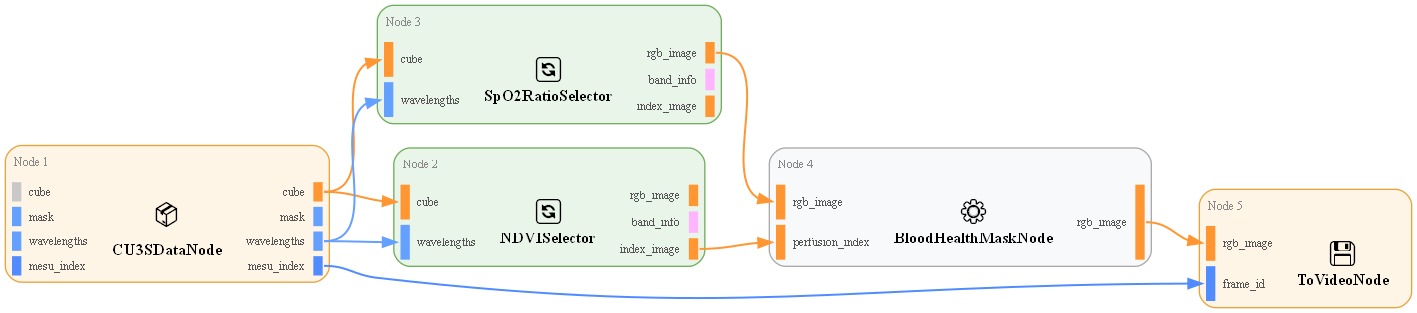

In [13]:
adv_graph_png = advanced_pipeline.visualize(
    format="render_graphviz",
    output_path=str(output_dir / f"{advanced_pipeline.name}.png"),
    # show_execution_stage=True,
)
display(Image(str(adv_graph_png)))

Predict [BloodPerfusion_SpO2_Masked]:   0%|          | 0/1 [00:00<?, ?batch/s]

2026-06-18 12:09:44.858 | DEBUG    | cuvis_ai_dataloader.data.readers.cu3s_reader:__init__:47 - Opened cu3s ..\..\data\XMR_Demo_Blood_Perfusion\Auto_005.cu3s: 568 measurements, 61 channels


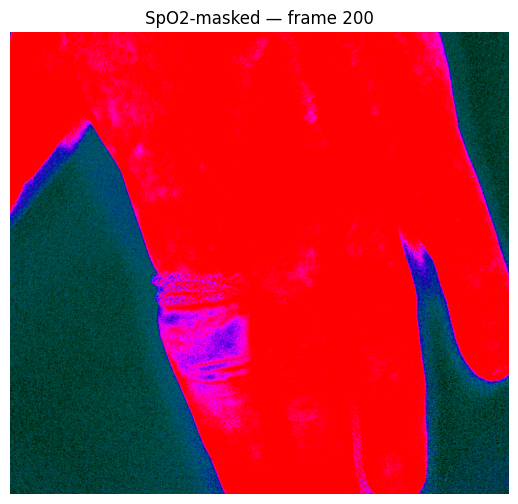

In [14]:
# Preview the advanced pipeline on PREVIEW_FRAME_ID (defined in §5).
# Reuses preview_datamodule from §5; writes a one-frame .mp4 to
# advanced_output_path that the full run below overwrites.
advanced_pipeline.to(device)
adv_preview_outputs = Predictor(pipeline=advanced_pipeline, datamodule=preview_datamodule).predict(
    collect_outputs=True
)

adv_preview_rgb = adv_preview_outputs[0][("health_mask", "rgb_image")][0].cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(adv_preview_rgb)
plt.title(f"SpO2-masked — frame {PREVIEW_FRAME_ID}")
plt.axis("off")
plt.show()

In [15]:
advanced_pipeline.to(device)

advanced_predictor = Predictor(pipeline=advanced_pipeline, datamodule=datamodule)
advanced_predictor.predict(max_batches=N_FRAMES, collect_outputs=False)

if not advanced_output_path.exists():
    raise RuntimeError(f"Expected output video was not created: {advanced_output_path}")

logger.success("SpO2-masked export complete: {}", advanced_output_path)

2026-06-18 12:09:45.841 | DEBUG    | cuvis_ai_dataloader.data.readers.cu3s_reader:__init__:47 - Opened cu3s ..\..\data\XMR_Demo_Blood_Perfusion\Auto_005.cu3s: 568 measurements, 61 channels


Predict [BloodPerfusion_SpO2_Masked]:   0%|          | 0/568 [00:00<?, ?batch/s]

2026-06-18 12:09:46.436 | DEBUG    | cuvis_ai_dataloader.data.readers.cu3s_reader:__init__:47 - Opened cu3s ..\..\data\XMR_Demo_Blood_Perfusion\Auto_005.cu3s: 568 measurements, 61 channels
2026-06-18 12:11:03.693 | SUCCESS  | __main__:<module>:9 - SpO2-masked export complete: output\blood_perfusion\spo2_proxy_masked.mp4


In [16]:
display(Video(str(advanced_output_path), embed=IN_COLAB, width=640))